# Hubbard Model with $t'$

Author: Kyle Eskridge

In this tutorial, we will perform AFQMC calculations for the Hubbard model with $t'$ on
a 4x8 lattice.
The Hamiltonian is given by,
$$
\hat{H} = -t \sum_{\langle i,j\rangle^{(1)}} \hat{c}^\dagger_i \hat{c}_j -t' \sum_{\langle i,j\rangle^{(2)}} \hat{c}^\dagger_i \hat{c}_j + U \sum_{i} \hat{n}^{\uparrow}_i \hat{n}^{\downarrow}_i,
$$
where $i,j$ are lattice site indices, angle brackets with superscript $(n)$ indicate
that sums are constrained to $n^{th}$-order neighbors,
$\hat{c}^\dagger_i$/$\hat{c}_i$ are electronic creation/anihilation operators,
and $\hat{n}^{\sigma}_i$ are spin-resolved number operators corresponding to site $i$.
The 4x4 lattice is small enough to make exact diagonaliztion possible.
We will use exact results for this system as reference data throughout
this tutorial.

See Table I of reference [1]
The AFQMC energy using a free-electron Trial wavefunction is, for $U=4$ on a 4x8 square lattice
with $N_{\uparrow} = N_{\downarrow} = 16$, $−27.271⁢(1)$ versus $−27.6924$ from DMRG.
(Better AFQMC results exist there when using a self-consistent procedure).

References:

1. https://journals.aps.org/prresearch/abstract/10.1103/PhysRevResearch.3.013065

In [ ]:
%load_ext autoreload
%autoreload
# simple setup
from tutorial_utils import run_afqmc, get_scratch_dir

#TODO: update this to a good directory for scratch files
scratch_rootdir="/mnt/home/beskridge/ceph/scratch/11"
scratch_dir = get_scratch_dir("04_hubbard_tprime",scratch_rootdir)

## Setup - Make a lattice

computing and storing 1th-nearest neighbors
Computing distance matrix of lattice
Reading lattice site positions from Lattice
computing and storing 1th-nearest image neighbors


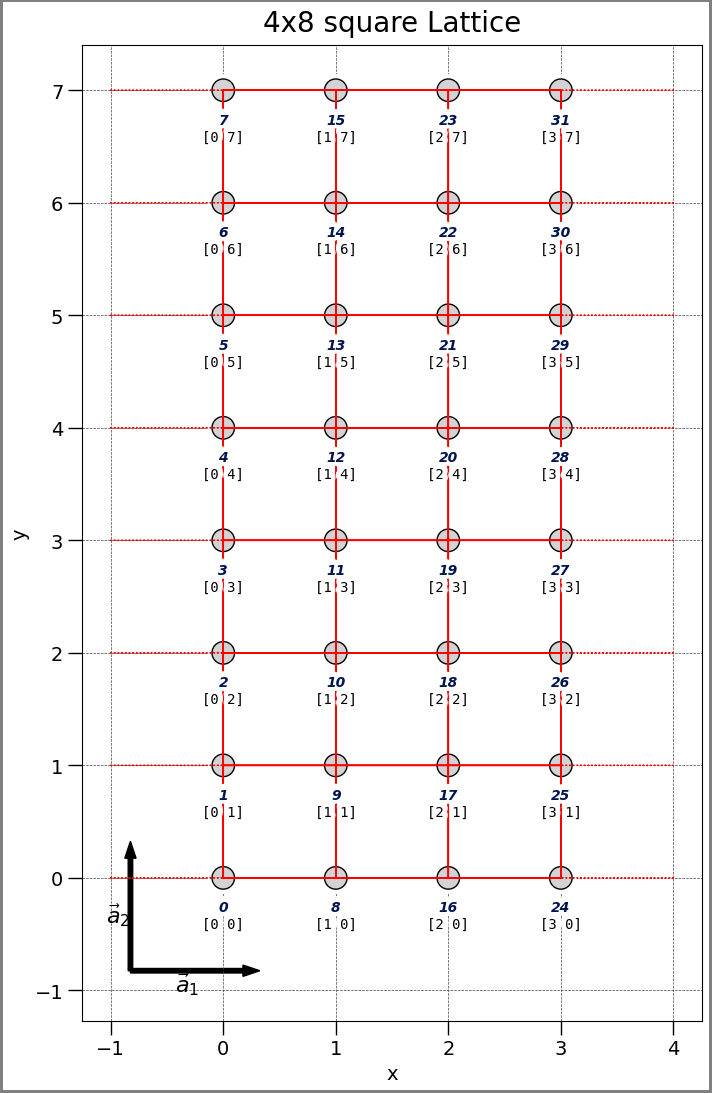

(<Figure size 800x1600 with 1 Axes>,
 <Axes: title={'center': '4x8 square Lattice'}, xlabel='x', ylabel='y'>)

In [ ]:
%autoreload
from afqmctools.systems.lattice import get_lattice
from afqmctools.utils.visualize import plot_lattice

lattice_params = {
    "L1" : 4,
    "L2" : 8,
    "boundary1" : "pbc",
    "boundary2" : "open"
}

lattice = get_lattice(lattice_params)

plot_lattice(lattice,show_coords=False)

## Setup - Make the Hamiltonian

...

In [ ]:
%autoreload
from afqmctools.hamiltonian.model.director import HamiltonianDirector
from afqmctools.utils.io import write_model_hamiltonian

#TODO: need AFM (staggered) pinning at y=1 and  y=Ly with h_pin = 0.25 only for AFQMC!!

hamiltonian_params = {
    "hamiltonian" : {
        "t" : [1.0,0.3],
        "U" : 4
    }
}

director = HamiltonianDirector(hamiltonian_params,lattice=lattice)

# we can take more direct control of build steps like this
builder = director.release_builder()
builder.afm_pinning(h_afm_pin=0.25,axis=1,pin_type="same")

# ... and we can resume using the director as usual
director.bind_builder(builder)

hamiltonian = director.build()
write_model_hamiltonian(hamiltonian,fname=scratch_dir/"Hubbard_tprime0.4_U4.0.h5")

Using afm pin type: same
running build step nth_neighbor_hopping(([1.0, 0.3],))
Calling wrapper with 1.0 for nth_neighbor=1
Using same twists for up and down spins
Calling wrapper with 0.3 for nth_neighbor=2
Using same twists for up and down spins
running build step onsite_hubbard((4,))
Building Hubbard U term with U=4
Building onsite hubbard with positive U values: 4
Combining terms of the same type
Combining tij terms
Combining Hubbard U, U1, and U2 terms where possible
Max spin symmetry is  2


## Setup - Trial Wavefunction.

In [ ]:
# First, let's compute the Free-Electron trial wavefunction
from afqmctools.wavefunction.free_electron import free_electron

nelec =(16,16)

input_params = dict(
    lattice = lattice_params,                           # from step 1. above
    hamiltonian = hamiltonian_params["hamiltonian"]     # from step 2. above
)

# twist from ref 1:
twist = (0.0,0.0) #(0.01,0.01) # this twist was used for 4x16 with t' = 0.3t
_,_,results = free_electron(
    source=input_params,
    nelec=nelec,
    twist=twist,                          # (optional) using the defaul small twist
    output=scratch_dir/"free_elec_wfn.h5",           # set output file to save the wavefunction in.
    return_autohf = True
)

Generating free-electron trial wavefunction with twist = [0. 0.]
running build step nth_neighbor_hopping(([1.0, 0.3],))
Calling wrapper with 1.0 for nth_neighbor=1
computing and storing 1th-nearest neighbors
Computing distance matrix of lattice
Reading lattice site positions from Lattice
computing and storing 1th-nearest image neighbors
Using same twists for up and down spins
Calling wrapper with 0.3 for nth_neighbor=2
computing and storing 2th-nearest neighbors
computing and storing 2th-nearest image neighbors
Using same twists for up and down spins
running build step onsite_hubbard((4,))
Building Hubbard U term with U=4
Building onsite hubbard with positive U values: 4
Combining terms of the same type
Combining tij terms
Combining Hubbard U, U1, and U2 terms where possible
Max spin symmetry is  2
using dense representation of 1-body Hamiltonian to find eigenvalues and orbitals
Eigenvalues of the non-interacting Hamiltonian:  [-5.00701639 -4.45134222 -3.6        -2.55567417 -1.8793852

/mnt/ceph/users/beskridge/software/AuxiliaryFields/utils/afqmctools/wavefunction/common.py:166: UserWarning: Using UHF Slater determinant for initial Walkers with a Collinear Trial Wavefunction. This can lead to very slow equilibration in AFQMC calculations. using ROHF Slater determinants for intiail Walkers is recommended.
  warn(


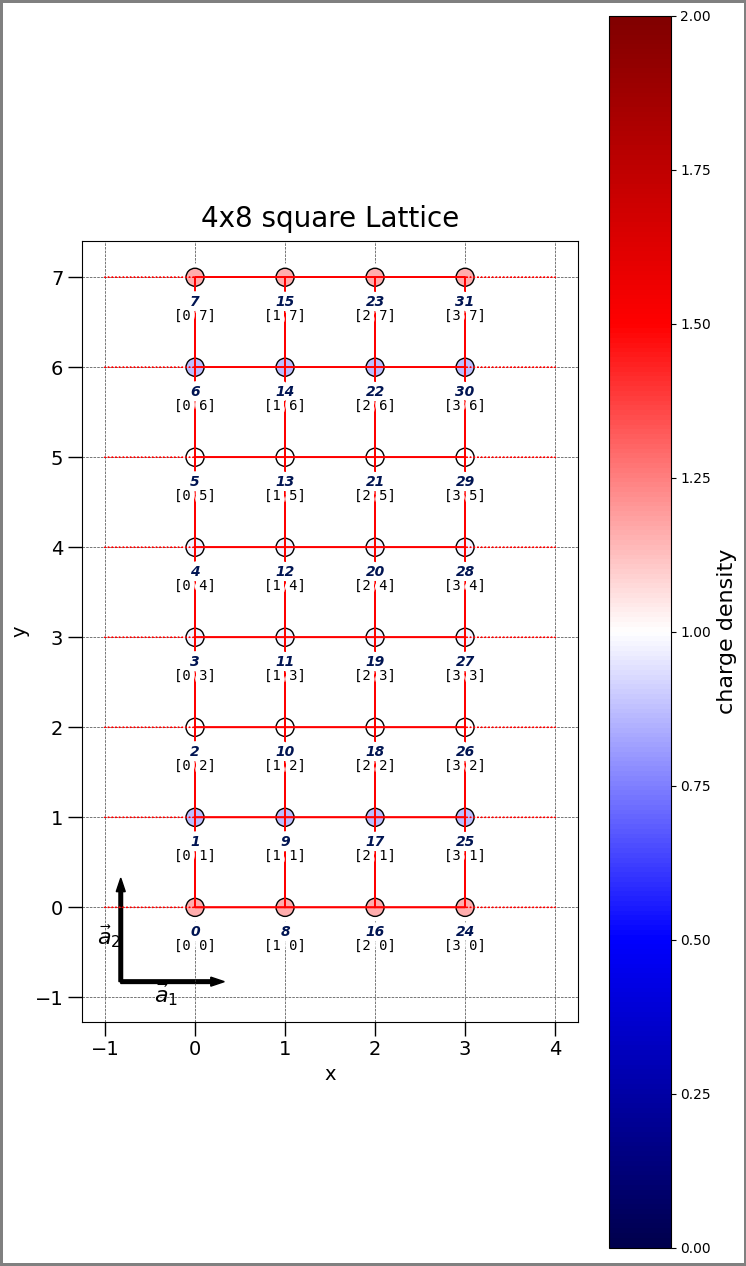

(<Figure size 800x1600 with 2 Axes>,
 <Axes: title={'center': '4x8 square Lattice'}, xlabel='x', ylabel='y'>)

In [ ]:
import afqmctools.utils.visualize as vis

# convert the 'results' from autohf to a charge density
makeRDMs = results['makeRDMs']
state = results['state']

rdm = makeRDMs(state)

# get lattice dimensions from the Lattice instance
L = lattice.L

# collinear
rho_up = rdm[0].diagonal().reshape(*L)
rho_down = rdm[1].diagonal().reshape(*L)

rho_charge = rho_up + rho_down
#rho_spin = 0.5*(rho_up - rho_down)

vis.plot_lattice(
    lattice,
    density=rho_charge.real,
    density_label="charge density",
    vmin=0.0,
    vmax=2.0
)

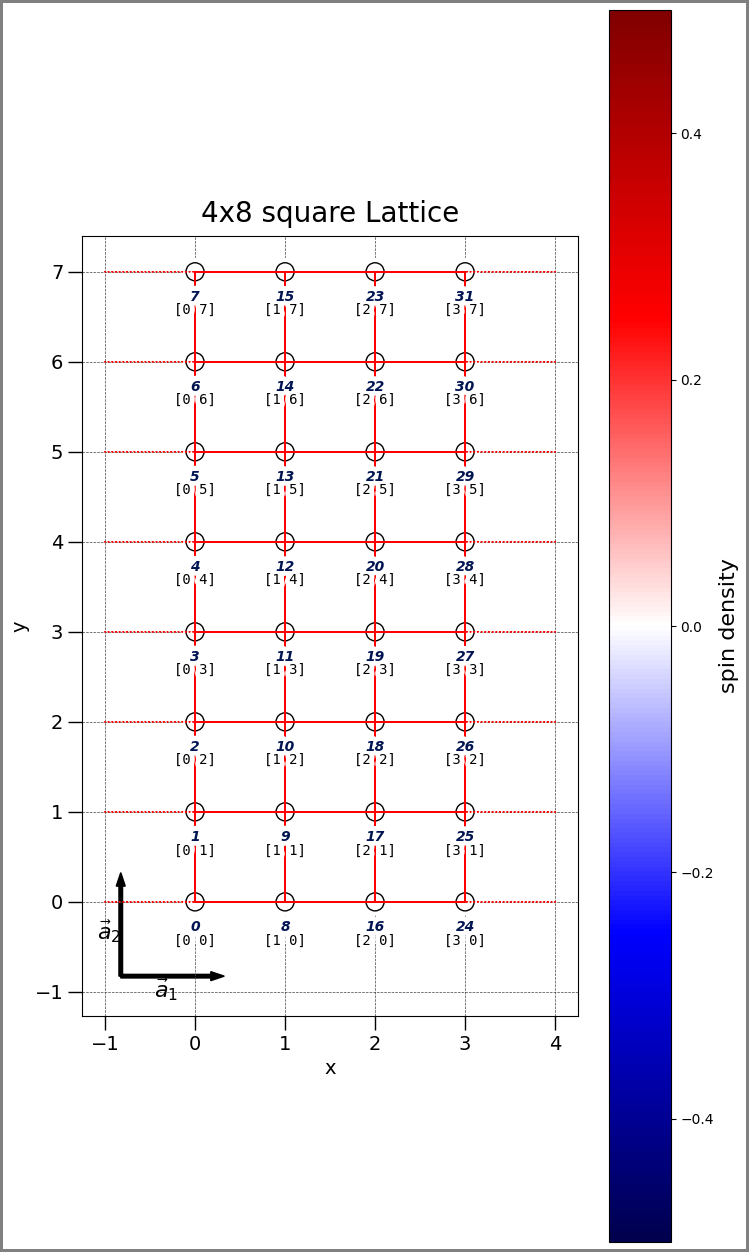

(<Figure size 800x1600 with 2 Axes>,
 <Axes: title={'center': '4x8 square Lattice'}, xlabel='x', ylabel='y'>)

In [ ]:
rho_spin = 0.5*(rho_up - rho_down)
vis.plot_lattice(
    lattice,
    density=rho_spin.real,
    density_label="spin density",
    vmin=-0.5,
    vmax=0.5
)

## Setup - Write an AuxiliaryFields input file

In [ ]:
# make a json input file
from afqmctools.inputs.from_hdf import write_json

afqmc_params = {
    "timestep": 0.01,
    "steps": 12000,
    "n_walkers_per_mpi_task": 30,
    "population_control_interval": 5,
    "walker_ortho_interval": 5,
    "measure_interval": 10,
    "seed" : 42,                          # for reproducibility
    "propagator": {
      "use_cp_constraint": True,
      "use_real_vbias" : True
    },
      "estimator": {
        "name":"back_propagation",
        "path_restoration":True,
        "ortho":5,
        "nsteps":200,
        "naverages":4,
        "equil":2000,
        "onerdm" : {
          "name":"onerdm"
        }
      }
}

write_json(
    scratch_dir/"afqmc.json",
    fwfn0=scratch_dir/"free_elec_wfn.h5",
    fham0=scratch_dir/"Hubbard_tprime0.4_U4.0.h5",
    exec_opts=afqmc_params
)

### Running AFQMC

Below, we provide a cell that will run AFQMC here; however, for this calculation, you might prefer to submit the job to Slurm.
You can copy the runscript from `/mnt/home/beskridge/ceph/software/AuxiliaryFields/local_scripts/run_afqmc_cpu.sh` to your scratch
directory for this tutorial and use

```bash
sbatch run_afqmc_cpu.sh
```

to submit the job (perhaps adjusting the run time).


In [ ]:
run_afqmc(
    run_dir=scratch_dir,
    output_file=None,       # this will dump the output from AFQMC here
    np=16,                   # set number of MPI tasks
    timeout_mins=20
)

Running AFQMC locally with 16 mpi tasks
--------------------------------------------------------------------------
Ignoring value for oob_tcp_if_exclude on ccqlin053 (10.250.112.0/20: Did not find interface matching this subnet).
(You can safely ignore this message.)
--------------------------------------------------------------------------
   _____               .__.__  .__                      ___________.__       .__       .___     
  /  _  \  __ _____  __|__|  | |__|____ _______ ___.__. \_   _____/|__| ____ |  |    __| _/______
 /  /_\  \|  |  \  \/  /  |  | |  \__  \_  __ <   |  |  |    __)  |  |/ __ \|  |   / __ |/  ___/
/    |    \  |  />    <|  |  |_|  |/ __ \|  | \/\___  |  |     \   |  \  ___/|  |__/ /_/ |\___ \ 
\____|__  /____//__/\_ \__|____/__(____  /__|   / ____|  \___  /   |__|\___  >____/\____ /____  >
        \/            \/               \/       \/           \/            \/           \/    \/   
=====================================================================

226.32124725299946

## Analysis - compute the AFQMC energy

we're looking for −27.271⁢(1) from reference [1]

I'm currently at
-26.778445 +/- 0.009127.

Let's double check the paper.





====== [analyze_scalar_data Settings] ======

[+] fname            = /mnt/home/beskridge/ceph/scratch/11/04_hubbard_tprime/qmc.s000.scalar.dat
[+] shebang          = #               
[+] xaxis            = time            
[+] nequil           = 2.0             
[+] estimate_equil   = False           
[+] column           = LocalEnergy     
[+] reblock          = 1               
[+] list             = False           
[+] trace            = True            
[+] append           = None            
[+] dump             = False           
[+] dump_fname       = trace.dat       
[+] savefig          = None            
[+] ndiscard         = None            
[+] return_data      = False           
[+] autocorr         = None            
[+] verbose          = True            
[+] dump_avail_columns = False           

AFQMC Energy   -26.778445 +/-   0.009127 9.55  2.0/120.0


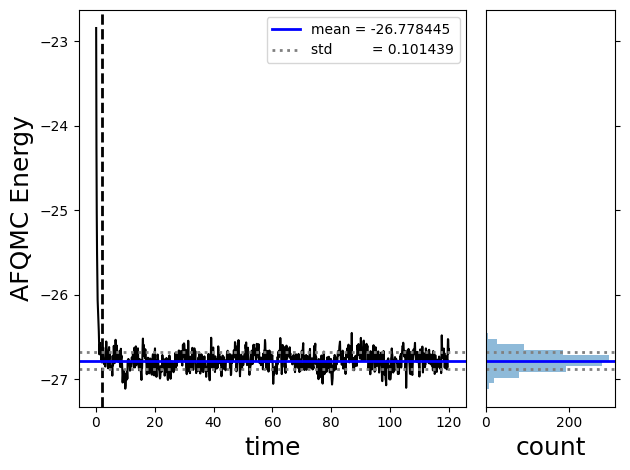

The AFQMC energy is -26.778445 +/- 0.009127 Hartree


In [ ]:
from stats.scalar_dat import analyze_scalar_data
nequil = 2.0 #t^{-1}

analysis_settings = dict(
    fname = scratch_dir/"qmc.s000.scalar.dat",
    xaxis = "time",     # use units of imaginary time for equilibration
    nequil = nequil,    # length of equilibration phase (in units of imaginary time)
    trace = True,       # plots a trace of the scalar data
)

E,dE = analyze_scalar_data(analysis_settings)

print(f"The AFQMC energy is {E:.6f} +/- {dE:.6f} Hartree")

ref_stoch_uncertainty = dE

## Analysis - compute the Average 1-rdm

To check for convergence here, we will compute the average 1-rdm for each "average" saved in the
output HDF5 file, and plot `\rho(i,j)` vs $N_{steps}$ for a line cut of the lattice.
We should see the average 1-rdm converge for some value of $N_{steps}$.

In [ ]:
from afqmctools.analysis.rdm import average_afqmc_rdm

naverages = 4

rho_avg, delta_rho = average_afqmc_rdm(rdm_file=scratch_dir/"qmc.s000.stat.h5")

rho_up = rho_avg[:,0,:,:].diagonal().reshape((naverages,4,8))
delta_rho_up = delta_rho[:,0,:,:].diagonal().reshape((naverages,4,8))

rho_down = rho_avg[:,1,:,:].diagonal().reshape((naverages,4,8))
delta_rho_down = delta_rho[:,1,:,:].diagonal().reshape((naverages,4,8))


(4, 4, 8)

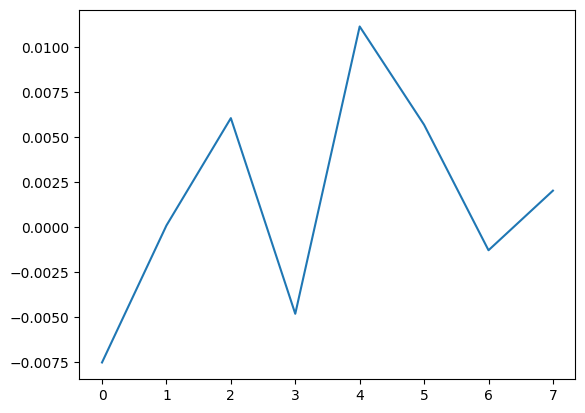

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

ix = 3
iy = np.array(range(8))

rho_spin = 0.5*(rho_up - rho_down)

plt.plot(iy,rho_spin[0,ix,iy])
plt.show()

## Improved Trial via Natural orbitals